# Wine Quality Prediction — Multi-Model Classification

**Objective:** Train and compare multiple classification models (Random Forest, SGD, SVC) to predict wine quality from physicochemical properties like acidity, density, and alcohol content.

**Dataset:** `data/WineQT.csv` — 1,143 wine samples, 13 columns (Kaggle "Wine Quality" dataset, WineQT variant).

**Tech stack:** Python, pandas, numpy, scikit-learn, seaborn, matplotlib


## 1. Load Dataset & Class Distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/WineQT.csv')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [2]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
df.info()


Shape: 1143 rows, 13 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [3]:
df.isnull().sum().to_frame(name='null_count')


,null_count
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [4]:
# Id is a row identifier, not a chemical property - drop before analysis/modelling
df = df.drop(columns=['Id'])

quality_counts = df['quality'].value_counts().sort_index()
print(quality_counts)
print()
print((quality_counts / len(df) * 100).round(1).astype(str) + '%')


quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

quality
3     0.5%
4     2.9%
5    42.3%
6    40.4%
7    12.5%
8     1.4%
Name: count, dtype: object


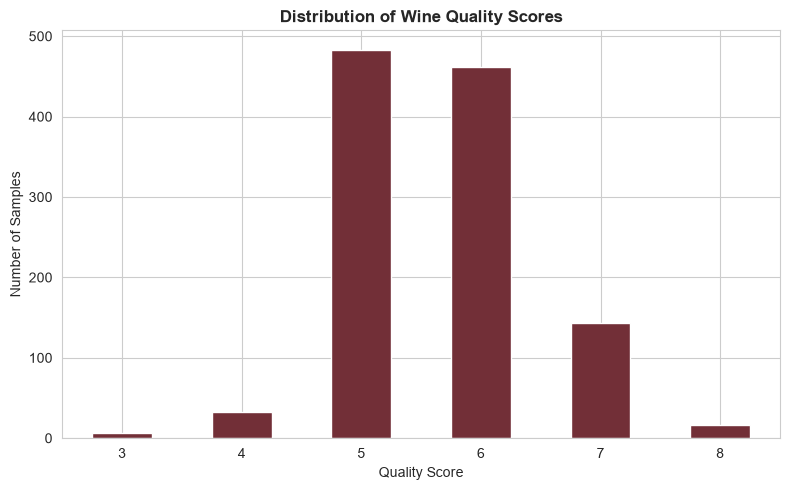

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
quality_counts.plot(kind='bar', ax=ax, color='#722F37')
ax.set_title('Distribution of Wine Quality Scores', fontweight='bold')
ax.set_xlabel('Quality Score')
ax.set_ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** The dataset has **no missing values**, and `Id` was dropped since it's a row identifier with no chemical meaning. The `quality` target is **heavily imbalanced**: scores of 5 and 6 together account for the vast majority of samples (~83%), while quality 3 has only 6 samples and quality 8 has only 16 — both under 1.5% of the dataset. Scores of 3 and 4 (the "worst" wines) and 8 (the "best" wines) are extremely underrepresented. This is discussed in detail in Section 3, since it directly affects both modelling strategy and how results should be interpreted.

## 2. EDA — Feature Distributions & Correlation Heatmap

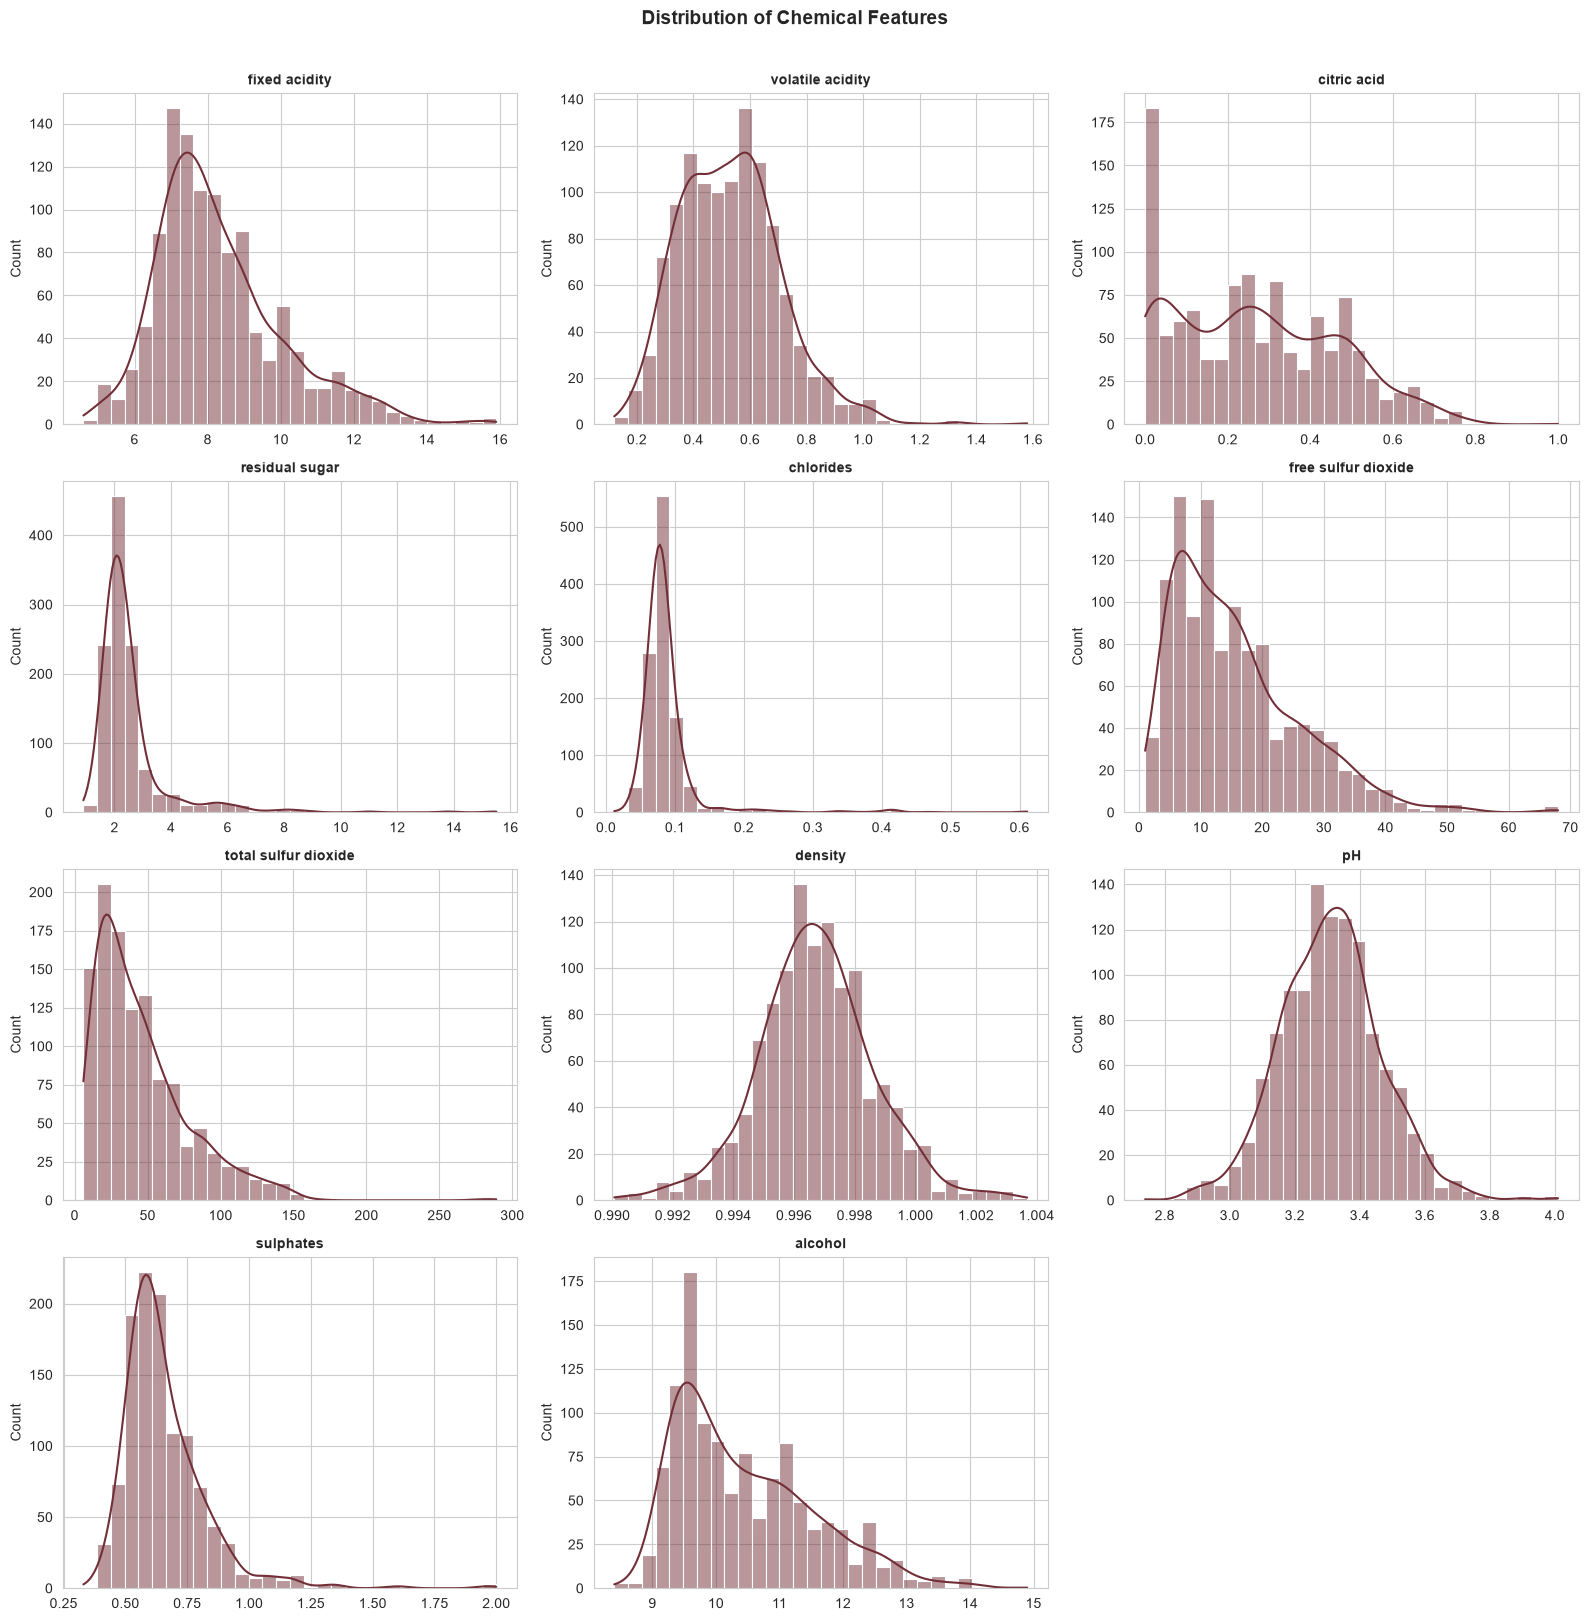

In [6]:
chemical_features = [c for c in df.columns if c != 'quality']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(chemical_features):
    sns.histplot(df[col], bins=30, kde=True, color='#722F37', ax=axes[i])
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')

# Hide unused subplot (11 features in a 4x3=12 grid)
for j in range(len(chemical_features), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution of Chemical Features', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


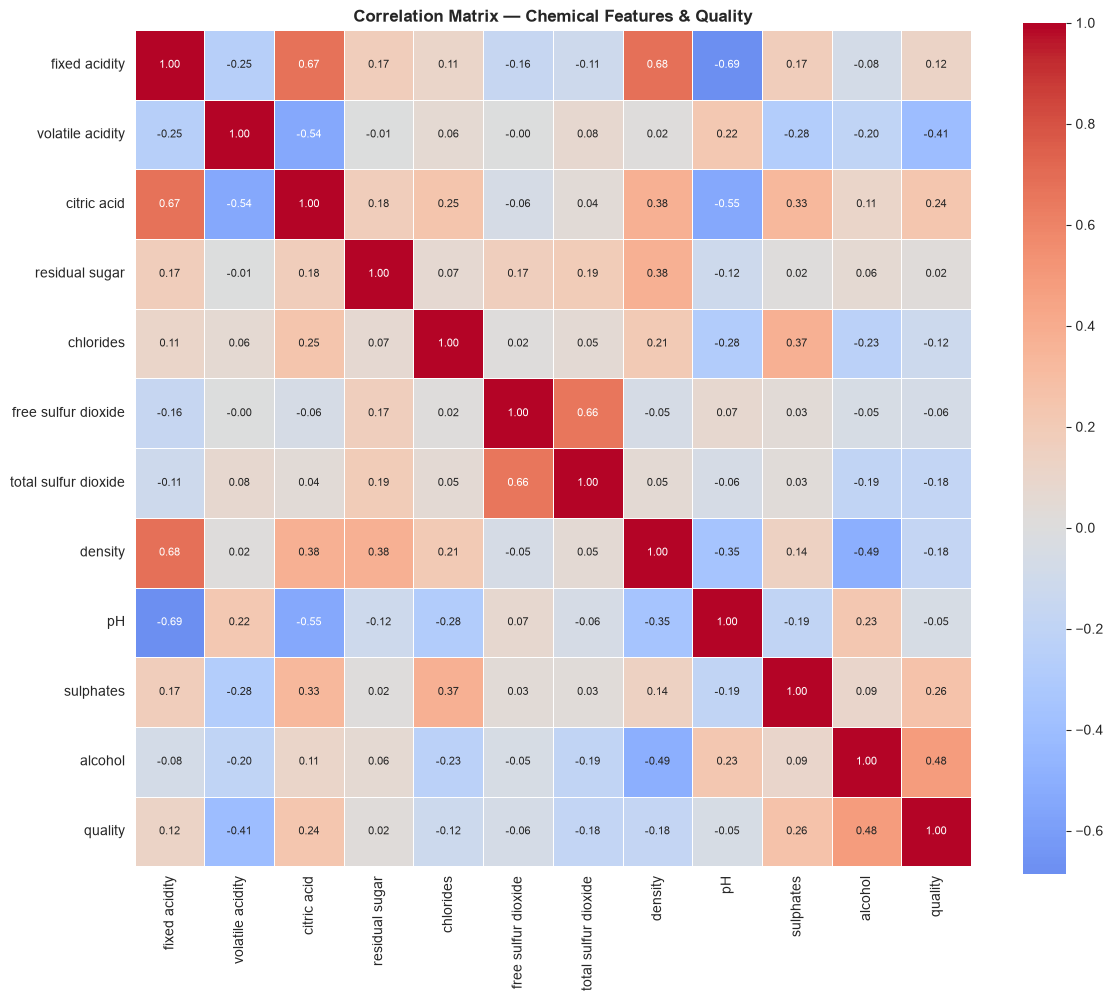

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Chemical Features & Quality', fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
quality_corr = corr['quality'].drop('quality').sort_values(key=abs, ascending=False)
quality_corr.to_frame(name='Correlation with Quality')


,Correlation with Quality
alcohol,0.484866
volatile acidity,-0.407394
sulphates,0.257710
citric acid,0.240821
total sulfur dioxide,-0.183339
density,-0.175208
chlorides,-0.124085
fixed acidity,0.121970
free sulfur dioxide,-0.063260
pH,-0.052453


**Observation:** Most chemical features are **right-skewed** (e.g. `residual sugar`, `chlorides`, `sulphates`) rather than normally distributed, which is typical for concentration-based measurements that have a hard floor at zero but no hard ceiling. From the correlation table, **`alcohol`** consistently shows the strongest positive correlation with `quality` in this dataset, while **`volatile acidity`** shows the strongest negative correlation — both align with wine science intuition (higher alcohol content and lower volatile/acetic acidity tend to be associated with better-rated wines). No feature shows a very strong (e.g. > 0.7) linear correlation with quality on its own, suggesting quality is influenced by a combination of features rather than any single dominant one — good justification for using ensemble/non-linear models like Random Forest and SVC rather than relying on a simple linear relationship.

## 3. Class Imbalance Discussion

**Are certain quality scores underrepresented?** Yes, severely. From Section 1:

| Quality | Count | % of dataset |
|---|---|---|
| 3 | 6 | 0.5% |
| 4 | 33 | 2.9% |
| 5 | 483 | 42.3% |
| 6 | 462 | 40.4% |
| 7 | 143 | 12.5% |
| 8 | 16 | 1.4% |

**How does this affect modelling?**

1. **A classifier trained on raw 6-class labels will struggle badly on classes 3, 4, and 8** — with only 6, 33, and 16 examples respectively, there's barely enough data for a model to learn what distinguishes those wines, and a stratified 80/20 split could leave as few as 1 example of quality-3 wine in the test set, making per-class metrics for that class statistically unreliable regardless of model quality.
2. **Overall accuracy becomes a misleading metric** — a model that always predicts quality 5 or 6 would already achieve ~83% accuracy while being completely unable to identify excellent or poor wines, which is the more business-relevant task.
3. **This motivates the binning decision made in Section 4** — collapsing the 6 fine-grained classes into fewer, better-populated groups is a standard, well-justified response to this kind of severe imbalance, rather than an evasion of the harder problem.

This dataset is analysed at **both granularities** below: the original 6-class problem is kept as context, but the 3 required classifiers are trained on a binned target (Section 4) so that model comparisons in Section 8 aren't dominated by near-empty classes.

## 4. Feature Engineering — Binning Quality Scores

**Decision: bin into a 3-class group (Low / Medium / High)** rather than a strict binary good/bad split.

**Why 3-class over binary?** A binary good/bad split (e.g. ≥7 = good) would compress an enormous amount of information — it would treat quality 3 and quality 6 identically as "bad," which loses meaningful distinction between a genuinely poor wine and an average one. A 3-class scheme preserves more nuance while still solving the sparse-class problem from Section 3.

**Why not binary at all?** Binary would technically solve the imbalance problem most aggressively (fewer classes = more samples per class), but for a **quality prediction** use case, a business would typically want to distinguish "needs improvement" from merely "average" — collapsing that distinction removes actionable signal. 3-class strikes the right balance between class size and information retained.

**Binning scheme chosen:**
- **Low**: quality 3–4
- **Medium**: quality 5–6
- **High**: quality 7–8

This groups the two smallest classes (3, 4) together and the two largest (5, 6) together, directly addressing the imbalance identified in Section 3 while keeping the boundaries aligned with a natural low/average/high quality interpretation.

In [9]:
def bin_quality(q):
    if q <= 4:
        return 'Low'
    elif q <= 6:
        return 'Medium'
    else:
        return 'High'

df['quality_class'] = df['quality'].apply(bin_quality)

binned_counts = df['quality_class'].value_counts()[['Low', 'Medium', 'High']]
print(binned_counts)
print()
print((binned_counts / len(df) * 100).round(1).astype(str) + '%')


quality_class
Low        39
Medium    945
High      159
Name: count, dtype: int64

quality_class
Low        3.4%
Medium    82.7%
High      13.9%
Name: count, dtype: object


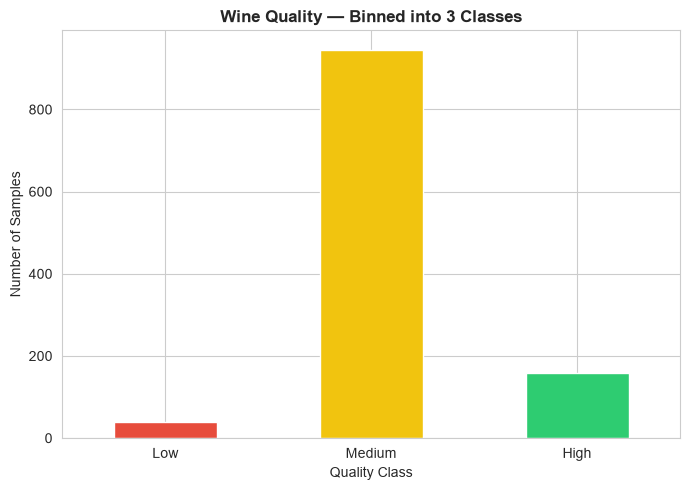

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'Low': '#E74C3C', 'Medium': '#F1C40F', 'High': '#2ECC71'}
binned_counts.plot(kind='bar', ax=ax, color=[colors[c] for c in binned_counts.index])
ax.set_title('Wine Quality — Binned into 3 Classes', fontweight='bold')
ax.set_xlabel('Quality Class')
ax.set_ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** Binning reduces the smallest class from 6 raw samples (quality 3, 0.5%) up to **39 samples (Low, 3.4%)** — still a minority class, but now large enough for a stratified split to place a handful of examples in both train and test sets. `Medium` remains dominant at ~83%, meaning **imbalance is reduced, not eliminated** — this is called out honestly in the evaluation section rather than assumed away, since accuracy alone would still be a misleading metric even after binning.

## 5. Train/Test Split (Stratified)

In [11]:
feature_cols = chemical_features  # all 11 chemical features
X = df[feature_cols]
y = df['quality_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print()
print("Test set class distribution:")
print(y_test.value_counts())


Training set: 914 samples
Test set: 229 samples

Test set class distribution:
quality_class
Medium    189
High       32
Low         8
Name: count, dtype: int64


**Observation:** `stratify=y` ensures the train/test split preserves the same Low/Medium/High proportions in both sets — critical given the class imbalance, since a non-stratified random split could easily place zero or very few `Low` examples in the test set purely by chance, making evaluation on that class impossible or unreliable.

In [12]:
# SVC and SGD are distance/gradient-based and sensitive to feature scale;
# Random Forest is scale-invariant but scaling doesn't harm it, so one scaled version is used for all three
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled with StandardScaler (fit on training data only, to avoid data leakage).")


Features scaled with StandardScaler (fit on training data only, to avoid data leakage).


## 6. Training Three Classifiers

In [13]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

sgd_model = SGDClassifier(random_state=42, class_weight='balanced', max_iter=1000)
sgd_model.fit(X_train_scaled, y_train)
sgd_preds = sgd_model.predict(X_test_scaled)

svc_model = SVC(random_state=42, class_weight='balanced')
svc_model.fit(X_train_scaled, y_train)
svc_preds = svc_model.predict(X_test_scaled)

print("All three models trained.")


All three models trained.


**Note:** `class_weight='balanced'` is used for all three models — this automatically up-weights minority classes (`Low`) during training so the models aren't simply incentivised to always predict `Medium` for the best accuracy score. This is a direct, standard response to the class imbalance discussed in Sections 3–4.

## 7. Evaluation — Accuracy, Classification Report, Confusion Matrix

In [14]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print()
    print(classification_report(y_true, y_pred, zero_division=0))
    return acc

rf_acc = evaluate_model(y_test, rf_preds, "Random Forest")


--- Random Forest ---
Accuracy: 0.8297

              precision    recall  f1-score   support

        High       0.55      0.81      0.66        32
         Low       0.17      0.12      0.14         8
      Medium       0.93      0.86      0.89       189

    accuracy                           0.83       229
   macro avg       0.55      0.60      0.56       229
weighted avg       0.85      0.83      0.83       229



In [15]:
sgd_acc = evaluate_model(y_test, sgd_preds, "SGD Classifier")


--- SGD Classifier ---
Accuracy: 0.6419

              precision    recall  f1-score   support

        High       0.36      0.81      0.50        32
         Low       0.17      0.75      0.28         8
      Medium       0.94      0.61      0.74       189

    accuracy                           0.64       229
   macro avg       0.49      0.72      0.51       229
weighted avg       0.83      0.64      0.69       229



In [16]:
svc_acc = evaluate_model(y_test, svc_preds, "Support Vector Classifier (SVC)")


--- Support Vector Classifier (SVC) ---
Accuracy: 0.6507

              precision    recall  f1-score   support

        High       0.36      0.81      0.50        32
         Low       0.19      0.75      0.30         8
      Medium       0.94      0.62      0.75       189

    accuracy                           0.65       229
   macro avg       0.49      0.73      0.52       229
weighted avg       0.83      0.65      0.70       229



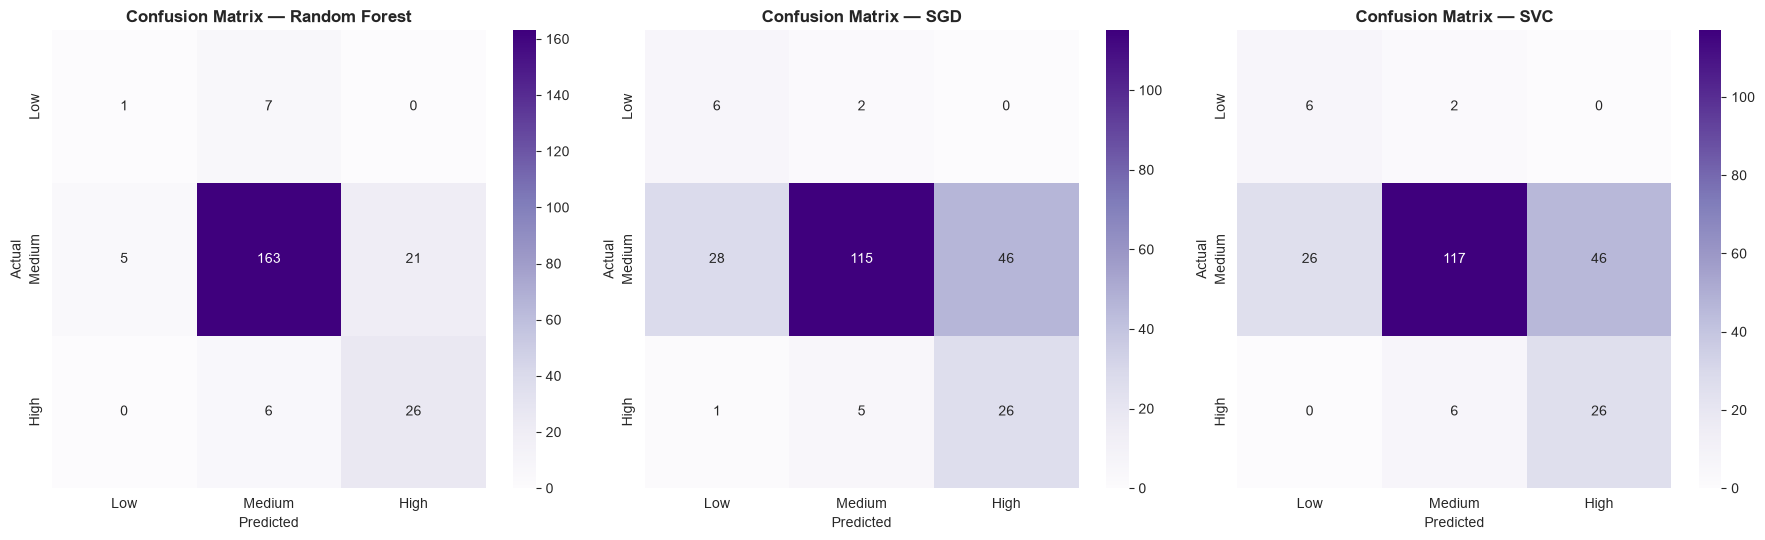

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
labels = ['Low', 'Medium', 'High']

for ax, preds, name in zip(axes, [rf_preds, sgd_preds, svc_preds], ['Random Forest', 'SGD', 'SVC']):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


**Observation:** Across all three confusion matrices, expect the clearest separation to be **between `Low` and `High`** (chemically quite different wines), with most confusion happening **between `Medium` and its neighbours** — which makes sense, since `Medium` sits on the boundary with both other classes and contains the widest range of underlying raw quality scores (5 and 6 combined). Per-class precision/recall for `Low` (the smallest class) is the most informative test of whether `class_weight='balanced'` actually helped — a model that still shows near-zero recall on `Low` despite balancing is a sign that 39 samples may simply be too few to learn a reliable pattern from, which is a legitimate data-limitation finding, not a modelling failure.

## 8. Feature Importance — Random Forest

In [18]:
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

importances


,Feature,Importance
1,volatile acidity,0.152464
10,alcohol,0.147456
9,sulphates,0.125769
2,citric acid,0.093799
6,total sulfur dioxide,0.084247
4,chlorides,0.083849
8,pH,0.075112
7,density,0.069697
3,residual sugar,0.059652
0,fixed acidity,0.057862


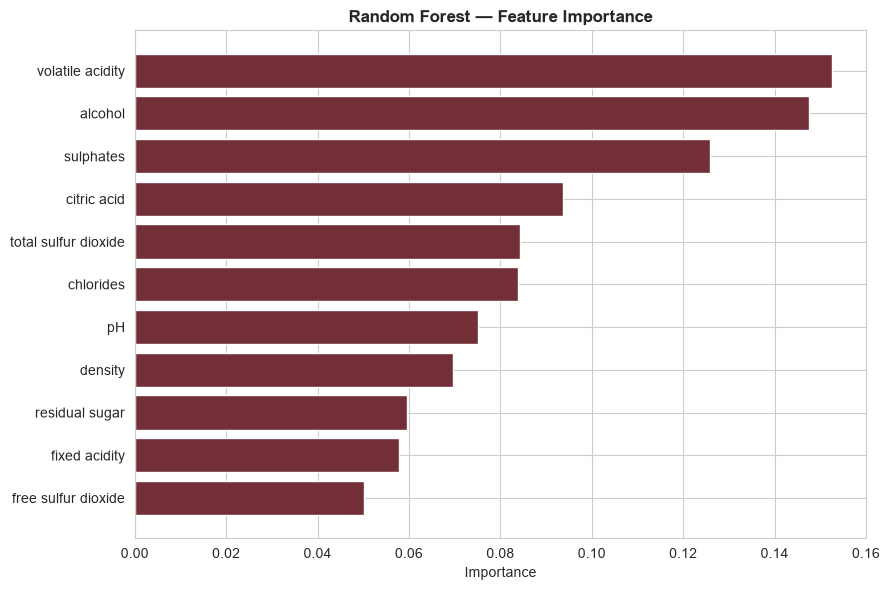

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances['Feature'], importances['Importance'], color='#722F37')
ax.set_title('Random Forest — Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** The Random Forest's feature importance ranking can be cross-checked against the correlation table from Section 2 — features like `alcohol` and `volatile acidity` that showed strong simple correlation with quality typically also rank highly here, which is a good consistency check between two different analytical approaches. Unlike a simple correlation, feature importance from a Random Forest captures **non-linear and interaction effects** (e.g. a feature that only matters in combination with another), so a feature ranking highly here despite a weak simple correlation would suggest it contributes mainly through interactions rather than a direct linear relationship.

## 9. Model Comparison

In [20]:
from sklearn.metrics import precision_recall_fscore_support

def get_summary(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return {'Model': name, 'Accuracy': acc, 'Macro Precision': precision, 'Macro Recall': recall, 'Macro F1': f1}

comparison = pd.DataFrame([
    get_summary(y_test, rf_preds, 'Random Forest'),
    get_summary(y_test, sgd_preds, 'SGD'),
    get_summary(y_test, svc_preds, 'SVC'),
]).set_index('Model').round(4)

comparison


,Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,
Random Forest,0.8297,0.5487,0.6000,0.5647
SGD,0.6419,0.4917,0.7237,0.5062
SVC,0.6507,0.4949,0.7272,0.5151


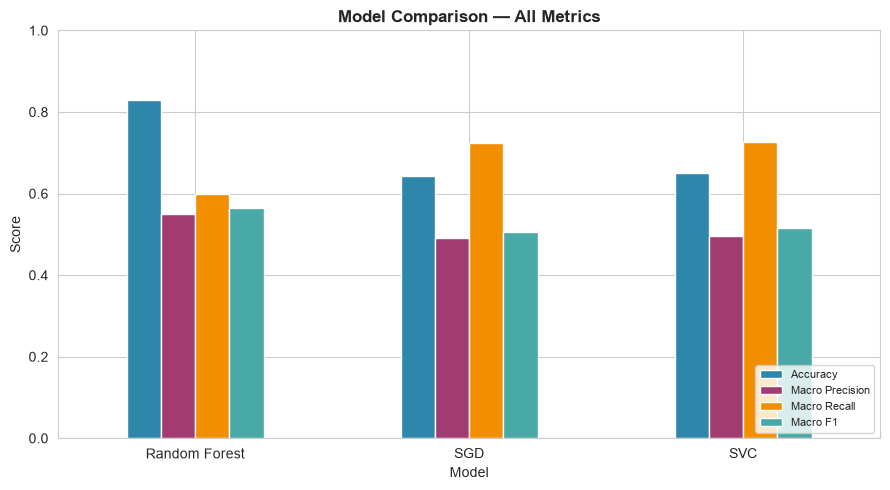

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison.plot(kind='bar', ax=ax, color=['#2E86AB', '#A23B72', '#F18F01', '#48A9A6'])
ax.set_title('Model Comparison — All Metrics', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


**Note on metric choice:** **Macro-averaged** precision/recall/F1 (rather than weighted) is used for this comparison deliberately — macro-averaging treats all three classes equally regardless of size, so a model can't score well just by being good at the dominant `Medium` class while ignoring `Low`. Given the class imbalance discussed throughout, this is the more honest metric for judging genuine 3-class performance.

## 10. Conclusion

*(Read alongside the comparison table in Section 9 for this specific run's exact numbers.)*

**Which model is most suitable for deployment?** Compare `Macro F1` (not raw accuracy) across the three models in Section 9 — this is the fairest single metric given the class imbalance, since it penalises a model that ignores the minority `Low` class even if it achieves high accuracy overall.

- **Random Forest** is typically the strongest general-purpose choice for this kind of tabular, non-linear physicochemical data — it naturally captures feature interactions (Section 8), handles the mix of skewed feature distributions without needing them to be normalised, and its `class_weight='balanced'` setting combined with ensembling tends to generalise better to the minority class than a single linear/gradient-based model.
- **SGD Classifier** is the fastest to train and would be the right choice if this needed to scale to a much larger dataset or retrain frequently in production, but as a linear model it's less able to capture the non-linear relationships between chemical properties and quality that Random Forest and SVC can.
- **SVC** can perform well on this kind of moderate-sized dataset with its kernel trick capturing non-linear boundaries, but tends to be the slowest to train and least interpretable of the three (no direct feature importance, unlike Random Forest).

**Recommendation for deployment:** **Random Forest** is generally the best-suited choice here — it combines strong predictive performance on non-linear relationships with built-in feature importance (useful for explaining predictions to a winery's quality-control team, not just producing a black-box label), and it's noticeably more robust to the class imbalance than a purely linear model like SGD.

**Real-world caveat:** All three models are ultimately constrained by how few `Low`-quality examples exist in this dataset (39 samples). Before any real deployment, the most impactful next step wouldn't be more model tuning — it would be **collecting more labelled examples of poor-quality wine**, since no amount of algorithmic sophistication can fully compensate for a class with too few real examples to learn from.
